## Import

In [3]:
import numpy as np
from itertools import product
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import SearchForPatterns as sfp

## Global

### Paths

In [4]:
#paths for the data that will be generated
root = "./data"
patterns_path = root + "/patterns"
trajectories_path = root + "/trajectories"
pinned_trajectories_path = root + "/pinned_trajectories"
patterns_1D_path = root + "/patterns/1D"
patterns_1D_space_path = root + "/patterns/1D/space" # for patterns along the 1D space at a single time step
patterns_1D_time_path = root + "/patterns/1D/time" # for patterns along the time axis at a single space cell
patterns_2D_path = root + "/patterns/2D" # means we have both space and time dimensions for 1D CAs


### Variables

In [5]:
# global CA parameters
width = 5 # width of the 1D cellular automaton
n_steps = 2**width # number of steps to simulate
initial_states = [np.array(bits) for bits in product([0, 1], repeat=width)] # all possible initial states
rules = [30, 45, 73, 110, 150, 105, 54, 22, 60, 146, 126, 62, 90, 18, 122, 26, 154, 94, 41, 57, 156, 28, 58, 78,
            178, 77, 50, 13, 25, 37, 9, 35, 106, 3, 27, 43, 184, 56, 11, 142, 14, 134, 24, 7, 152, 170, 46, 15, 33,
            1, 42, 162, 6, 5, 138, 38, 10, 74, 34, 29, 130, 2, 204, 200, 172, 108, 76, 72, 51, 44, 104, 232, 140, 132,
            23, 12, 164, 36, 19, 4, 168, 40, 160, 136, 128, 32, 8, 0]

### Loading the patterns

In [6]:
# assumed generation parameters
test_width_1D = 5
test_height_1D = 5

# load the patter of 1D space
with open(patterns_1D_space_path + f"/all_pattern_counts_{width}_{test_width_1D}_1_1_1", "rb") as f:
    patterns_1D_space = pickle.load(f)

# load the pattern of 1D time
with open(patterns_1D_time_path + f"/all_pattern_counts_{width}_1_{test_height_1D}_1_1", "rb") as f:
    patterns_1D_time = pickle.load(f)

# load the pattern of 2D
test_width_2D = 3
test_height_2D = 3
with open(patterns_2D_path + f"/all_pattern_counts_{width}_{test_width_2D}_{test_height_2D}_1_1", "rb") as f:
    patterns_2D = pickle.load(f)


## Utility

### Convert a string looking like an array of bits to an actual array

In [7]:
def bitstring_to_array(s: str) -> np.ndarray:
    """
    Convert a string with 0s and 1s to a numpy array of integers (0s and 1s)
    Args:
        s: string with 0s and 1s
    Returns:
        numpy array with 0s and 1s
    """
    return np.array([int(c) for c in s if c in "01"])

#### Example

In [8]:
print(bitstring_to_array("01010101"))
print(bitstring_to_array("sgr0sgr1sgr0sgr1"))

[0 1 0 1 0 1 0 1]
[0 1 0 1]


### Log scaling

In [93]:
def logScaling(_sizes, _base = 10, _normalize=False, _shift=0, _scale=1):
    """
    Logarithmic scaling of the sizes of the nodes.
    Args:
        _sizes (numpy array): sizes of the nodes
        _base (int): base of the logarithm
        _normalize (boolean): whether to normalize the sizes
        _shift (float): shift of the sizes
        _scale (float): scale of the sizes
    Returns:
        log sizes (accordingly shifted and scaled).
    """
    _sizes = np.log(_sizes)/np.log(_base) # log scaling
    if _normalize:
        _sizes = _sizes - min(_sizes) # shift to [0, max-min]
        _sizes = _sizes / max(_sizes) # normalize to [0, 1]
    _sizes = _sizes + _shift # shifting [min+shift, max+shift]
    _sizes = _sizes * _scale # scaling [scale*min, scale*max]
    return _sizes

#### Example

In [94]:
# Example 1: Scaling a simple array of sizes with normalization, shift, and scale
sizes = np.array([10, 100, 1000, 10000])
print("Original sizes:", sizes)

print("\nUsing log base 10 for scaling:")

# Case 1: Default parameters
scaled_sizes_1 = logScaling(sizes)
print("\nCase 1 - Default - No Normalization, Shift=0, Scale=1")
print("Scaled sizes:", scaled_sizes_1)

# Case 3: Normalization, shift=0, scale=1
scaled_sizes_2 = logScaling(sizes, _normalize=True, _shift=0, _scale=1)
print("\nCase 2 - Normalized, Shift=0, Scale=1")
print("Scaled sizes:", scaled_sizes_2)

# Case 5: Normalization, shift=1, scale=10
scaled_sizes_3 = logScaling(sizes, _normalize=True, _shift=1, _scale=10)
print("\nCase 3 - Normalization, Shift=1, Scale=10")
print("Scaled sizes:", scaled_sizes_3)

Original sizes: [   10   100  1000 10000]

Using log base 10 for scaling:

Case 1 - Default - No Normalization, Shift=0, Scale=1
Scaled sizes: [1. 2. 3. 4.]

Case 2 - Normalized, Shift=0, Scale=1
Scaled sizes: [0.         0.33333333 0.66666667 1.        ]

Case 3 - Normalization, Shift=1, Scale=10
Scaled sizes: [10.         13.33333333 16.66666667 20.        ]


### Drawing bit arrays

In [20]:
def array_to_patches(_array, _square_size=1, _lw=1):
    """
    Convert an array of 0s and 1s to patches of black & white squares.

    Args:
        _array (numpy.ndarray): Array of 0s and 1s.
        _square_size (int): Size of each square.
        _lw (int): Line width of the patches.

    Returns:
        list of matplotlib.patches.Patch: List of patches representing the array.
    """
    squares = []
    for i, bit in enumerate(_array):
        color = 'black' if bit == 1 else 'white'
        squares += [patches.Rectangle((i * _square_size, 0), _square_size, _square_size, facecolor=color, edgecolor='black', linewidth=_lw)]
    return squares

#### Example

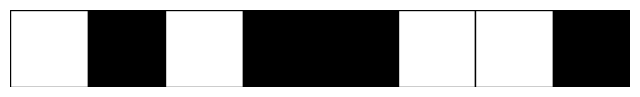

In [12]:

array = np.array([0, 1, 0, 1, 1, 0, 0, 1])
fig, ax = plt.subplots(figsize=(8, 2))
for patch in array_to_patches(array):
    ax.add_patch(patch)
ax.set_xlim(0, len(array))
ax.set_ylim(0, 1)
ax.set_aspect('equal')
plt.axis('off')
plt.show()

### Custom Pie Chart patches in matplotlib

In [ ]:
# Function to draw pie chart in the given matplotlib axis
def draw_pie(_ax, _ratios,
             _X=0, _Y=0, _size=1, 
             _colors=['red', 'blue', 'green', 'orange'],
             _lines=True, _lw=0.5):
    """
    Draw a pie chart on a given matplotlib axis.

    Args:
        ax (matplotlib.axes.Axes): The axis to draw the pie chart on.
        ratios (list of float): The ratios for the pie chart. Should sum to 1 or less.
        X (float): The x-coordinate of the center of the pie chart.
        Y (float): The y-coordinate of the center of the pie chart.
        size (float): The radius of the pie chart.
        colors (list of str): The colors for the pie chart segments.
        lines (bool): Whether to draw lines from the center of the pie chart to the segments.
        lw (float): The line width for the lines.
    """
    # Warn if the sum of ratio is bigger than 1
    if sum(_ratios) > 1:
        print(f"[draw_pie] Warning: sum of ratios is bigger than 1 --> {_ratios}, {sum(_ratios)}")

    # Adapt the colors to the number of ratios by cycling through the colors
    colors = _colors
    if len(_colors) < len(_ratios):
        n = len(_ratios) // len(_colors) + 1
        colors = _colors * n

    start_angle = 0
    for r, c in zip(_ratios, colors):
        end_angle = start_angle + r * 360
        wedge = patches.Wedge((_X, _Y), _size, start_angle, end_angle, facecolor=c)
        _ax.add_patch(wedge)
        if _lines:
            _ax.plot([_X, _X + _size * np.cos(np.radians(start_angle))], [_Y, _Y + _size * np.sin(np.radians(start_angle))], color='black', lw=_lw)
        start_angle = end_angle

#### Example

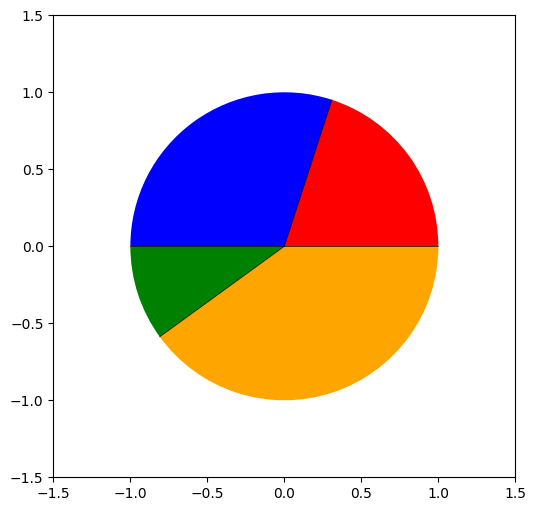

In [14]:
# Drawing a pie chart using draw_pie

# Create a figure and axis
fig, ax = plt.subplots(figsize=(6, 6))

# Define the ratios for the pie chart
ratios = [0.2, 0.3, 0.1, 0.4]

# Draw the pie chart
draw_pie(ax, ratios,
         _X=0, _Y=0, _size=1,
         _colors=['red', 'blue', 'green', 'orange'],
         _lines=True)

# Set the limits and aspect ratio
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')

# Display the plot
plt.show()


### Scatter plot of pie charts

In [15]:
def scatter_pies(_ax, _xData, _yData, _ratios,
                 _size=1, _colors=['red', 'blue', 'green', 'orange'], _lines=True):
    """
    Scatter plot with pie charts for each point.

    Args:
        _ax (matplotlib.axes.Axes): The axis to draw the scatter plot on.
        _xData (list of float): The x-coordinates of the points.
        _yData (list of float): The y-coordinates of the points.
        _pies (list of list of float): The pie charts for each point.
        _size (float): The size of the pie charts.
        _colors (list of str): The colors for the pie chart segments.
        _lines (bool): Whether to draw lines from the center of the pie chart to
            the segments.
    """

    # Warning if the number of points and pies do not match
    if len(_xData) != len(_yData) or len(_xData) != len(_ratios):
        print("[scatter_pies] Warning: number of points and pies do not match")
        print(f"[scatter_pies] xData: {len(_xData)}, yData: {len(_yData)}, pies: {len(_ratios)}")
        print("[scatter_pies] Ignoring the extra points or pies")

    for x, y, rs in zip(_xData, _yData, _ratios):
        draw_pie(_ax, rs, _X=x, _Y=y, _size=_size, _colors=_colors, _lines=_lines)

#### Example

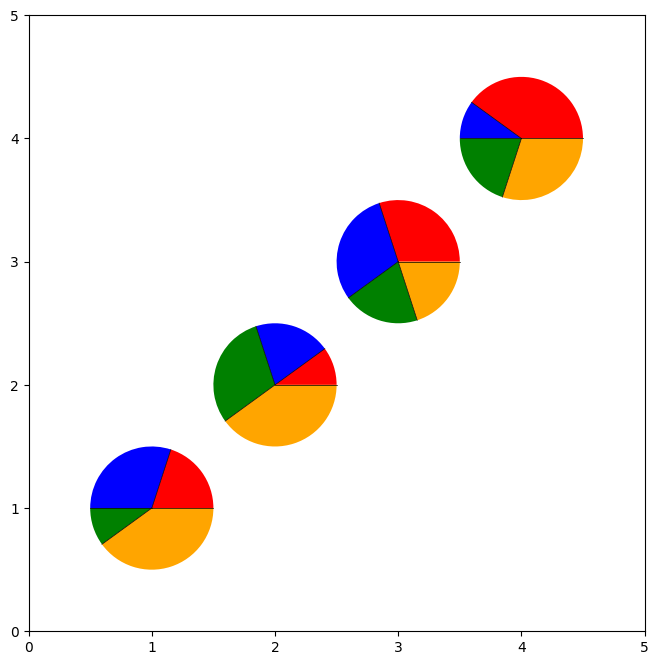

In [16]:
# Example data for scatter_pies
xData = [1, 2, 3, 4]
yData = [1, 2, 3, 4]
pies = [
    [0.2, 0.3, 0.1, 0.4],
    [0.1, 0.2, 0.3, 0.4],
    [0.3, 0.3, 0.2, 0.2],
    [0.4, 0.1, 0.2, 0.3]
]

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 8))

# Use scatter_pies to plot the data
scatter_pies(ax, xData, yData, pies,
             _size=0.5, _colors=['red', 'blue', 'green', 'orange'], _lines=True)

# Set the limits and aspect ratio
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_aspect('equal')

# Display the plot
plt.show()

### Pattern diversity as a scatter of pie charts of the patterns ratios.

In [124]:
def plot_patterns_diversity(_ax, _scanWindow, _patternsData, _rules, _ICs, _pieSizeScaling=5, _colormap='coolwarm', _ICcellSize=1):
    """
    Plot patterns as scatter of pie charts.

    Args:
        _ax (matplotlib.axes.Axes): The axis to draw the scatter plot on.
        _scanWindow (SearchWindow): A search window with the same properties as the one used to find the patterns.
        _patternsData (dict): Dictionary containing pattern data for each rule.
        _rules (list of int): List of CA rules (their integer names).
        _ICs (list of str): List of initial conditions (as bitstrings).
        _pieSizeScaling (float): Scaling factor for the size of the pie charts.
        _colormap (str): Colormap for the pie chart segments.
        _ICcellSize (int): Size of a square representing a cell of the CA's initial condition. Used to adapt the Yticks.
    """

    # Build log scale for the sizes of the pies based on the total population of the patterns
    sizes = [np.count_nonzero(_patternsData[rule][_ic]) for rule in _rules for _ic in _ICs]
    sizes = logScaling(sizes, _normalize=True, _shift=1, _scale=_pieSizeScaling)
    sizes = sizes.reshape((len(_rules), -1))  # Reshape to match the rules and initial conditions

    scatter_step = 2 * _pieSizeScaling * 2  # Set the step size based on the size of the pies

    cmap = plt.get_cmap(_colormap)  # Get the colormap

    nbICs = len(_ICs)
    ICwidth = bitstring_to_array(_ICs[0]).shape[0]

    for ruleIdx, rule in enumerate(_rules):
        x = scatter_step * ruleIdx

        icIdx = 0
        for ic in _ICs:
            patternCounts = _patternsData[rule][ic]  # Get the pattern counts for the rule and IC
            
            y = scatter_step * _scanWindow.CA_2D_State_To_Integer(bitstring_to_array(ic))

            # Calculate the total population (sum of all pattern occurrences)
            total_population = sum(patternCounts)

            # Normalize the pattern counts to get the ratios for the pie chart
            ratios = patternCounts[patternCounts > 0] / total_population

            # Get the colors for the pie chart segments
            colors = [cmap(r)[:3] for r in ratios]

            # Draw the pie chart
            draw_pie(_ax, ratios, _X=x, _Y=y, _size=sizes[ruleIdx, icIdx], _colors=colors, _lines=False)

            # Increment the IC index
            icIdx += 1

    # Set the limits and aspect ratio
    _ax.set_xlim(-1 * scatter_step, scatter_step * (len(_rules) + 1))
    _ax.set_ylim(-1 * scatter_step, scatter_step * nbICs)
    _ax.set_aspect('equal')

    # Set the rule labels as the x-ticks
    _ax.set_xticks([i * scatter_step for i in range(len(_rules))])
    _ax.set_xticklabels(_rules, rotation=90)

    # Set the initial condition labels as the y-ticks
    # Convert the initial conditions into the black and white representation, using the array_to_patches function
    # and then add the patches to the _axis
    _ax.set_yticks([i * scatter_step for i in range(nbICs)])
    _ax.set_yticklabels(['' for _ in range(nbICs)])  # Clear default labels

    # Add patches as tick labels
    for i in range(nbICs):
        b_a_w = array_to_patches(initial_states[i], _square_size=_ICcellSize, _lw=0.05 * _ICcellSize)
        for patch in b_a_w:
            _ax.add_patch(patch)
            patch.set_xy([patch.xy[0] - ((_ICcellSize + 1) * ICwidth + 1 * scatter_step), patch.xy[1] + i * scatter_step - 0.5 * _ICcellSize])
            patch.set_clip_on(False)  # Ensure the patches are not clipped by the plot boundaries


## Descriptive analysis

### Distribution of patterns per rule

- Which rule/IC have the low diversity of pattern (with expected high count)? (i.e. creates a very uniform trajectory)
- Conversely, which rule/IC have the highest diversity of pattern (with expected low count)? (i.e. creates very diverse trajectory)

We can answer these questions by ploting a scatter of pie charts: 
- One pie chart per position (rule/IC)
- the color of the pie chart is the number of non-zero integer in the pattern array of the rule (i.e. number of patterns). Following thermometter gradient.
- the pie chart's parts are the count of each pattern in the total count (i.e. the weight of each pattern in the diversity of the population)

In [17]:
# Alias variable for the target data
patternsData = patterns_1D_space

# Alias variables for the window
windowWidth = test_width_1D
windowHeight = 1
patternWindow = sfp.PatternScanWindow(windowWidth, windowHeight)

[draw_pie] Warning: sum of ratios is bigger than 1 --> [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05
 0.05 0.05 0.05 0.05 0.05 0.05], <built-in function sum>
[draw_pie] Warning: sum of ratios is bigger than 1 --> [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05
 0.05 0.05 0.05 0.05 0.05 0.05], <built-in function sum>
[draw_pie] Warning: sum of ratios is bigger than 1 --> [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05
 0.05 0.05 0.05 0.05 0.05 0.05], <built-in function sum>
[draw_pie] Warning: sum of ratios is bigger than 1 --> [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05
 0.05 0.05 0.05 0.05 0.05 0.05], <built-in function sum>
[draw_pie] Warning: sum of ratios is bigger than 1 --> [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05
 0.05 0.05 0.05 0.05 0.05 0.05], <built-in function sum>
[draw_pie] Warning: sum of ratios is bigger than 1 --> [0.05 0.05 0.05 0.05 0.05 0.05

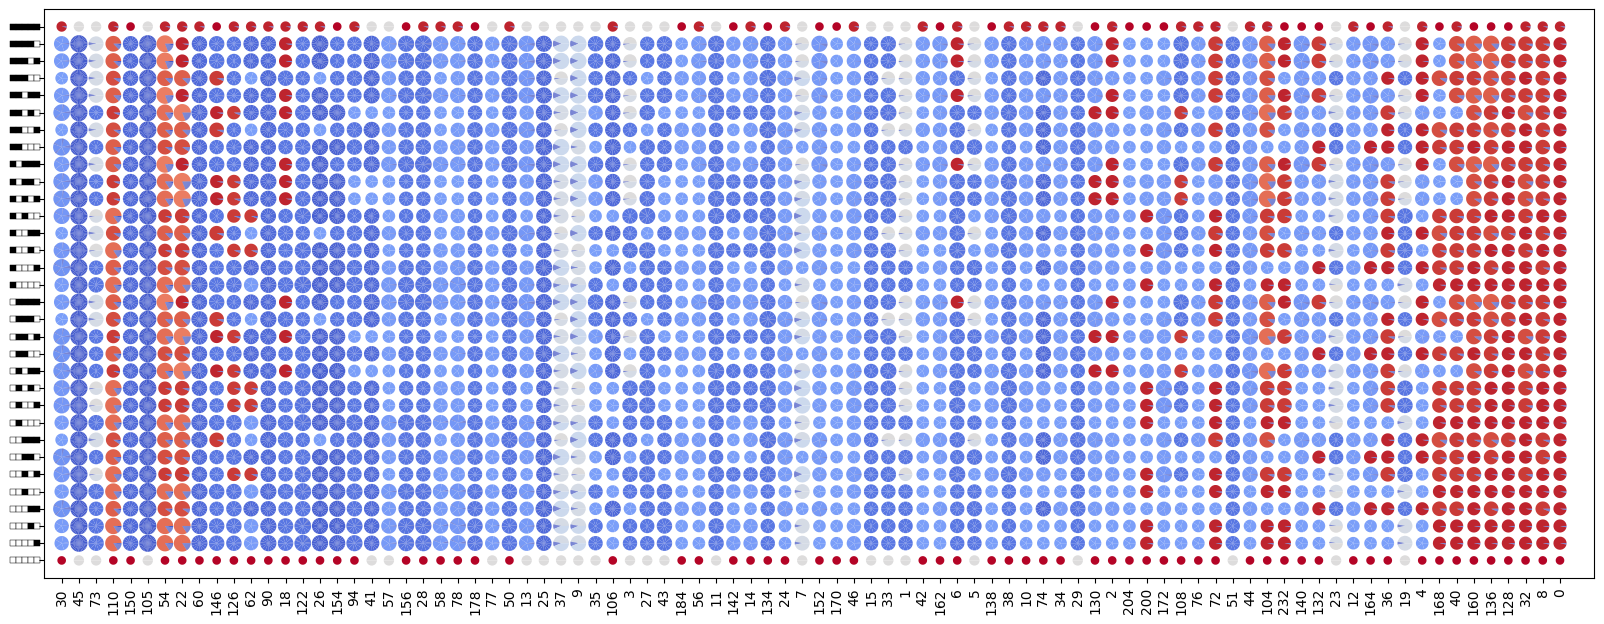

In [126]:
fig, ax = plt.subplots(figsize=(20, 20))
strICs=[str(ic) for ic in initial_states]
plot_patterns_diversity(ax, patternWindow, patternsData, rules, strICs, _pieSizeScaling=5, _colormap='coolwarm', _ICcellSize=7)
plt.show()

In this graph:
- small red points (such as in the row for IC = 0 or IC = 31), mean that a unique pattern was detected when scanning the CA trajectories (with a specific window size).
- large blue points mean that a high variety of patterns were detected
- white points mean that only two patterns dominate the trajectory
- larger red points mean that a pattern dominates many rare patterns.

In the context of control, if a rule switches from large blue to small red, it means the control achieved the fix the trajectory into a specific dynamic.